In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

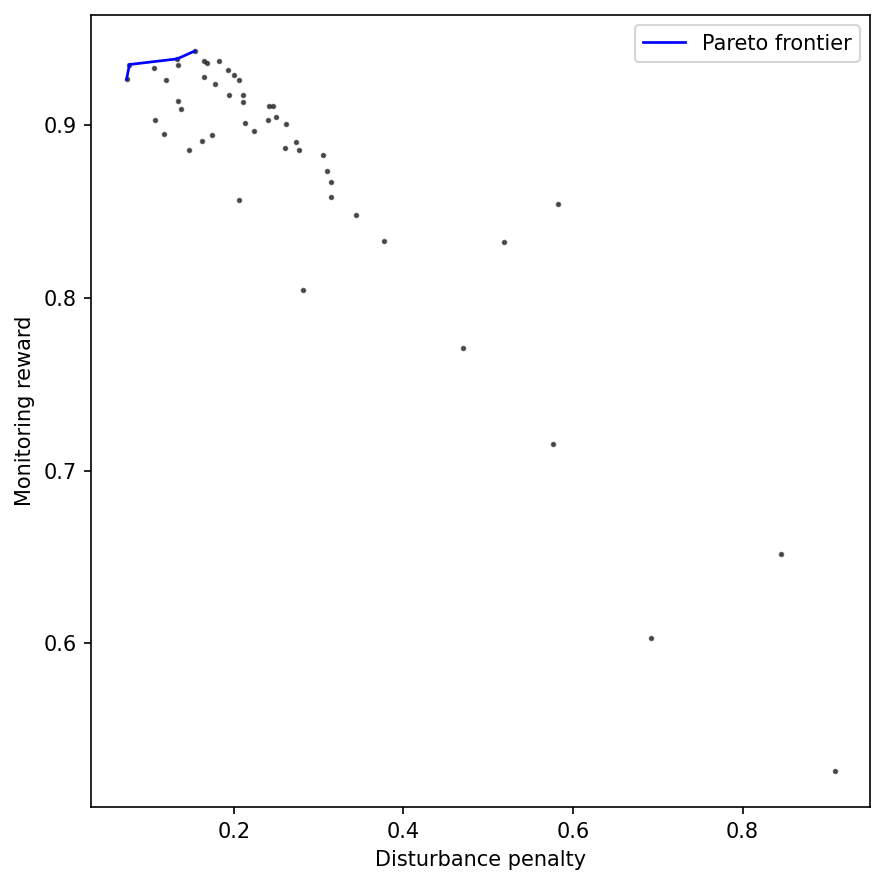

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

xcol = "p_disturbance"
ycol = "r_dist"

base_file = Path("pareto.csv")
sparse_file = Path("pareto_sparse.csv")

# load new results
df_new = pd.read_csv(base_file)

# load existing accumulated results if present
if sparse_file.exists():
    df_existing = pd.read_csv(sparse_file)
    df_all = pd.concat([df_existing, df_new], ignore_index=True)
else:
    df_all = df_new.copy()

# remove duplicates
df_all = df_all.drop_duplicates(subset=[xcol, ycol])

# save updated accumulated dataset
df_all.to_csv(sparse_file, index=False)

# ----- compute Pareto frontier -----
pts = df_all[[xcol, ycol]].dropna().to_numpy()

# sort by disturbance ascending, monitoring descending
pts = pts[np.lexsort((-pts[:, 1], pts[:, 0]))]

pareto = []
best_y = -np.inf

for px, py in pts:
    if py > best_y:
        pareto.append((px, py))
        best_y = py

pareto = np.array(pareto)

# ----- plot -----
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    df_all[xcol],
    df_all[ycol],
    s=11,
    alpha=0.65,
    color="#1C1C1C",
    marker="."
)

ax.plot(
    pareto[:, 0],
    pareto[:, 1],
    color="blue",
    linewidth=1.3,
    label="Pareto frontier"
)

ax.set_xlabel("Disturbance penalty")
ax.set_ylabel("Monitoring reward")

ax.legend()
plt.tight_layout()
plt.show()